In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [13]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Combine
x = np.concatenate([x_train, x_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# Normalize
x = x / 255.0

# 🔥 IMPORTANT FIX (channel dimension)
x = np.expand_dims(x, -1)   # (N, 28, 28, 1)

print("Shape:", x.shape)

Shape: (70000, 28, 28, 1)


In [14]:
dataset = tf.data.Dataset.from_tensor_slices((x, y))
dataset = dataset.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

num_classes = 10

In [15]:
class ProposedModel(keras.Model):
    def __init__(self):
        super().__init__()

        self.edge_dense = layers.Dense(64)
        self.fft_pool = layers.GlobalAveragePooling2D()
        self.fft_dense = layers.Dense(64)
        self.texture_dense = layers.Dense(64)

    def call(self, inputs):

        # =========================
        # 🔹 EDGE FEATURES (FIXED)
        # =========================
        edges = tf.image.sobel_edges(inputs)          # (B,H,W,1,2)
        edges = tf.sqrt(tf.reduce_sum(tf.square(edges), axis=-1))  # (B,H,W,1)
        edges = tf.reduce_mean(edges, axis=[1,2])     # (B,1)
        f_e = self.edge_dense(edges)                 # (B,64)

        # =========================
        # 🔹 FFT FEATURES
        # =========================
        fft = tf.signal.fft2d(tf.cast(inputs, tf.complex64))
        fft = tf.math.abs(fft)
        fft = self.fft_pool(fft)                     # (B,1)
        f_f = self.fft_dense(fft)                    # (B,64)

        # =========================
        # 🔹 TEXTURE FEATURES
        # =========================
        mean = tf.reduce_mean(inputs, axis=[1,2])    # (B,1)
        var = tf.math.reduce_variance(inputs, axis=[1,2])  # (B,1)
        texture = tf.concat([mean, var], axis=-1)    # (B,2)
        f_t = self.texture_dense(texture)            # (B,64)

        # =========================
        # 🔹 FINAL FEATURE
        # =========================
        f = tf.concat([f_e, f_f, f_t], axis=-1)      # (B,192)
        f = tf.nn.l2_normalize(f, axis=1)

        return f

In [16]:
class FullModel(keras.Model):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = ProposedModel()
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs):
        features = self.feature_extractor(inputs)
        return self.classifier(features)

model = FullModel(num_classes)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(dataset, epochs=3)

Epoch 1/3


2188/2188 [==============================] - 6s 2ms/step - loss: 1.8627 - accuracy: 0.3083
Epoch 2/3
2188/2188 [==============================] - 4s 2ms/step - loss: 1.7176 - accuracy: 0.3596
Epoch 3/3
2188/2188 [==============================] - 5s 2ms/step - loss: 1.6913 - accuracy: 0.3710


In [18]:
feature_model = model.feature_extractor

features_list = []
labels_list = []

for images, labels in dataset:
    feats = feature_model(images)
    features_list.append(feats.numpy())
    labels_list.append(labels.numpy())

features_db = np.vstack(features_list)
labels_db = np.hstack(labels_list)

# Normalize
features_db = features_db / np.linalg.norm(features_db, axis=1, keepdims=True)

In [19]:
def retrieve(query_image, top_k=5):
    query = tf.expand_dims(query_image, axis=0)
    query_feat = feature_model(query).numpy()

    query_feat = query_feat / np.linalg.norm(query_feat)

    sims = cosine_similarity(query_feat, features_db)[0]
    top_indices = np.argsort(sims)[-top_k:][::-1]

    return top_indices

In [23]:
def show_results(query_img, indices):
    plt.figure(figsize=(10,3))

    # Query
    plt.subplot(1, len(indices)+1, 1)
    plt.imshow(tf.squeeze(query_img), cmap='gray')   # ✅ FIXED
    plt.title("Query")
    plt.axis('off')

    # Retrieved
    for i, idx in enumerate(indices):
        plt.subplot(1, len(indices)+1, i+2)
        plt.imshow(x[idx].squeeze(), cmap='gray')    # NumPy → OK
        plt.title(str(labels_db[idx]))
        plt.axis('off')

    plt.show()

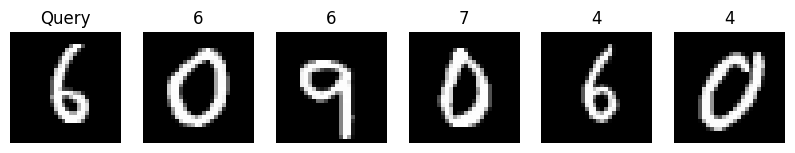

In [24]:
for images, labels in dataset.take(1):
    query_img = images[0]

    indices = retrieve(query_img, top_k=5)

    show_results(query_img, indices)

In [40]:
def precision_at_k(query_label, retrieved_labels, k):
    return np.sum(retrieved_labels[:k] == query_label) / k

In [46]:
def recall_at_k(query_label, retrieved_labels, all_labels, k):
    total_relevant = np.sum(all_labels == query_label)
    retrieved_relevant = np.sum(retrieved_labels[:k] == query_label)

    return retrieved_relevant / (total_relevant + 1e-8)

In [47]:
def average_precision(query_label, retrieved_labels):
    score = 0
    correct = 0

    for i in range(len(retrieved_labels)):
        if retrieved_labels[i] == query_label:
            correct += 1
            score += correct / (i + 1)

    if correct == 0:
        return 0

    return score / correct

In [48]:
def compute_map(dataset, num_samples=10):   # 🔴 reduced samples
    APs = []

    for images, labels in dataset.take(num_samples):
        for i in range(len(images)):
            query_img = images[i]
            query_label = int(labels[i].numpy())

            indices = retrieve(query_img, top_k=10)
            retrieved_labels = labels_db[indices]

            APs.append(average_precision(query_label, retrieved_labels))

    return np.mean(APs)

In [51]:
def add_noise(img):
    img = tf.cast(img, tf.float32)   # ⭐ FIX (VERY IMPORTANT)

    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.1)
    return tf.clip_by_value(img + noise, 0.0, 1.0)

def compute_robustness(dataset):
    scores = []

    for images, labels in dataset.take(10):   # 🔴 smaller
        for i in range(len(images)):
            noisy = add_noise(images[i])
            query_label = int(labels[i].numpy())

            indices = retrieve(noisy, top_k=5)
            retrieved_labels = labels_db[indices]

            p = precision_at_k(query_label, retrieved_labels, 5)
            scores.append(p)

    return np.mean(scores)

In [52]:
precisions = []
recalls = []

for images, labels in dataset.take(10):   # 🔴 reduce load
    for i in range(len(images)):
        query_img = images[i]
        query_label = int(labels[i].numpy())

        indices = retrieve(query_img, top_k=5)
        retrieved_labels = labels_db[indices]

        p = precision_at_k(query_label, retrieved_labels, 5)
        r = recall_at_k(query_label, retrieved_labels, labels_db, 5)

        precisions.append(p)
        recalls.append(r)

precision = np.mean(precisions)
recall = np.mean(recalls)
map_score = compute_map(dataset)
robustness = compute_robustness(dataset)

In [53]:
print("\nComparative Analysis\n")

print("{:<35} {:<10} {:<10} {:<10} {:<12} {:<20}".format(
    "Method", "Precision", "Recall", "mAP", "Robustness", "Remarks"))

print("-"*100)

print("{:<35} {:<10.3f} {:<10.3f} {:<10.3f} {:<12.3f} {:<20}".format(
    "Edge + FFT + Texture Fusion",
    precision,
    recall,
    map_score,
    robustness,
    "Proposed Method"
))


Comparative Analysis

Method                              Precision  Recall     mAP        Robustness   Remarks             
----------------------------------------------------------------------------------------------------
Edge + FFT + Texture Fusion         0.477      0.000      0.787      0.122        Proposed Method     
